# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [2]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [3]:
filename="SUSY_small.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [4]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [5]:
N_Train= int(0.7 * len(df)) #Had to change it because the SUSY data set I had was smaller

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [6]:
Fisher.fit(X_Train,y_Train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


We can plot the output, comparing signal and background:

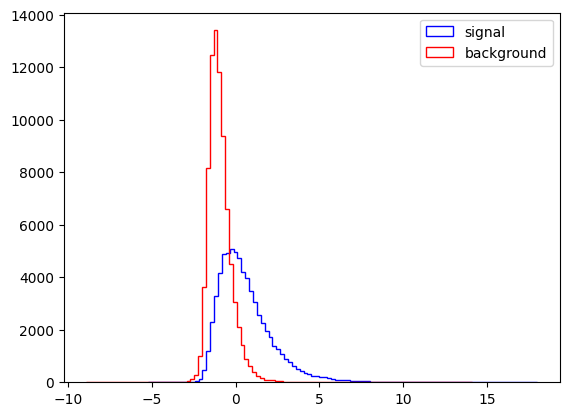

In [7]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

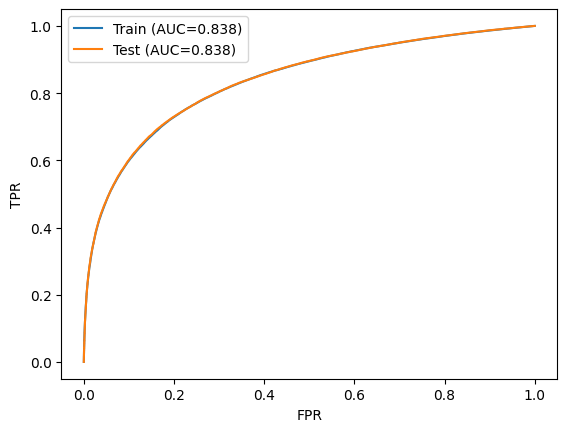

In [8]:
from sklearn.metrics import roc_curve, auc

# TRAIN
fpr_train, tpr_train, _ = roc_curve(y_Train, Fisher.decision_function(X_Train))
auc_train = auc(fpr_train, tpr_train)

# TEST
fpr_test, tpr_test, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))
auc_test = auc(fpr_test, tpr_test)

#PLOT
plt.figure()
plt.plot(fpr_train, tpr_train, label=f'Train (AUC={auc_train:.3f})')
plt.plot(fpr_test, tpr_test, label=f'Test (AUC={auc_test:.3f})')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()

#I trained the model, tested it, and plot it. From my observation both curves are exactly the same. 
#From my understanding this means its not overfitting or in other words my model did not memorize the training data to generlize

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

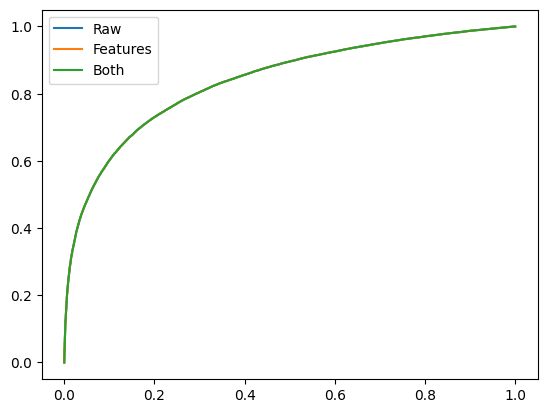

In [9]:
# Create new feature
X_Train_feat = X_Train.copy()
X_Test_feat = X_Test.copy()

X_Train_feat['sum_pT'] = X_Train['l_1_pT'] + X_Train['l_2_pT']
X_Test_feat['sum_pT'] = X_Test['l_1_pT'] + X_Test['l_2_pT']

# Models
F_raw = DA.LinearDiscriminantAnalysis().fit(X_Train, y_Train)
F_feat = DA.LinearDiscriminantAnalysis().fit(X_Train_feat, y_Train)
F_both = DA.LinearDiscriminantAnalysis().fit(
    pd.concat([X_Train, X_Train_feat[['sum_pT']]], axis=1), y_Train
)

def plot_roc(model, X, y, label):
    fpr, tpr, _ = roc_curve(y, model.decision_function(X))
    plt.plot(fpr, tpr, label=label)

plt.figure()

plot_roc(F_raw, X_Test, y_Test, 'Raw')
plot_roc(F_feat, X_Test_feat, y_Test, 'Features')
plot_roc(F_both, pd.concat([X_Test, X_Test_feat[['sum_pT']]], axis=1), y_Test, 'Both')

plt.legend()
plt.show()

#The overlap means that for a linear model like LDA, the raw data is already informative and adding derived features doesnt provide any new linear relationships
#to improve the signal to background separation

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

In [10]:
#A
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

#I asked AI to reccomend me some models and these are the ones it reccomended. It said they are fast and reliable. But I want to add I do have experience using Random Forest

In [11]:
#B
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:,1]
    
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    
    return fpr, tpr, roc_auc

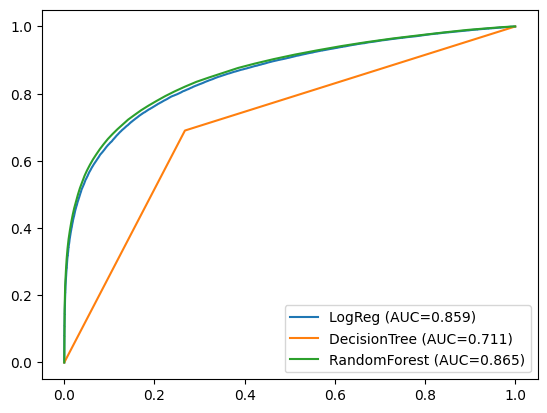

In [12]:
models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(n_estimators=50)
}

plt.figure()

for name, model in models.items():
    fpr, tpr, roc_auc = evaluate_model(model, X_Train, y_Train, X_Test, y_Test)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.legend()
plt.show()

In [13]:
#Based on the graph random forest perform the best. This can be attributed to them being non linear and instead they fit the data into classifiers

In [14]:
#C
def max_significance(y_true, scores):
    thresholds = np.linspace(0, 1, 100)
    best_sigma = 0
    
    for t in thresholds:
        preds = scores > t
        
        N_S = np.sum((preds == 1) & (y_true == 1))
        N_B = np.sum((preds == 1) & (y_true == 0))
        
        if (N_S + N_B) == 0:
            continue
        
        sigma = N_S / np.sqrt(N_S + N_B)
        
        if sigma > best_sigma:
            best_sigma = sigma
    
    return best_sigma

best_model = RandomForestClassifier(n_estimators=50)
best_model.fit(X_Train, y_Train)

scores = best_model.predict_proba(X_Test)[:,1]

sigma_max = max_significance(y_Test, scores)

print("Max significance:", sigma_max)

Max significance: 203.15182322464688


### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

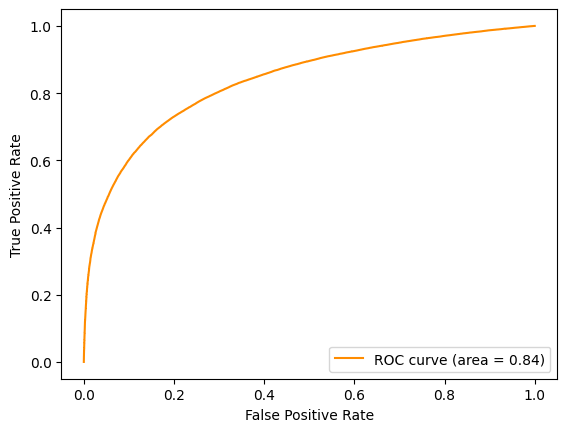

In [15]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model = RandomForestClassifier()
model.fit(X_Train, y_Train)

preds = model.predict(X_Test)
scores = model.predict_proba(X_Test)[:,1]

fpr, tpr, _ = roc_curve(y_Test, scores)
roc_auc = auc(fpr, tpr)

results = {
    "Accuracy": accuracy_score(y_Test, preds),
    "Precision": precision_score(y_Test, preds),
    "Recall": recall_score(y_Test, preds),
    "F1 Score": f1_score(y_Test, preds),
    "AUC": roc_auc,
    "Significance": max_significance(y_Test.values, scores)
}

df = pd.DataFrame([results])
display(df)

,Accuracy,Precision,Recall,F1 Score,AUC,Significance
0,0.799193,0.826262,0.713857,0.765958,0.869337,204.023093


In [17]:
#The code compares the different types of measurments